In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv("Book1.csv")

# Data Cleaning

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  str    
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: float64(1), 

In [5]:
df.describe(include='all') # give summary statistics for both numerical and categorical columns

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270000.000000,270000.000000,270000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.00000,270000.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,193405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,764999.500000,54.159870,NaN,3.315107,130.555089,245.045270,0.080052,0.978493,152.783756,0.274656,0.718082,1.459356,0.45480,4.619774
std,77942.430678,8.255471,NaN,0.851762,15.007908,33.695458,0.271374,0.998686,19.153454,0.446341,0.947417,0.546186,0.80127,1.950273
min,630000.000000,29.000000,NaN,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.00000,3.000000
25%,697499.750000,48.000000,NaN,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.00000,3.000000
50%,764999.500000,54.000000,NaN,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.00000,3.000000
75%,832499.250000,60.000000,NaN,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.00000,7.000000


In [6]:
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64

In [7]:
print(df.duplicated())

0         False
1         False
2         False
3         False
4         False
          ...  
269995    False
269996    False
269997    False
269998    False
269999    False
Length: 270000, dtype: bool


# Data Transformation

In [8]:
print(df.columns)

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='str')


In [9]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ","_")

In [10]:
df.columns

Index(['id', 'age', 'sex', 'chest_pain_type', 'bp', 'cholesterol',
       'fbs_over_120', 'ekg_results', 'max_hr', 'exercise_angina',
       'st_depression', 'slope_of_st', 'number_of_vessels_fluro', 'thallium'],
      dtype='str')

In [11]:
labels = ['Young','Middle-Aged','Senior']
df['age_group'] = pd.cut(df['age'], bins=[25,35,50,80], labels = labels , right = True , include_lowest= True )
# cut divides the age column into 3 range categorize , range is mentioned above but qcut split age into equal range for each label

In [12]:
df[['age','age_group']].head()

,age,age_group
0,58,Senior
1,55,Senior
2,54,Senior
3,44,Middle-Aged
4,43,Middle-Aged


In [13]:
df.columns

Index(['id', 'age', 'sex', 'chest_pain_type', 'bp', 'cholesterol',
       'fbs_over_120', 'ekg_results', 'max_hr', 'exercise_angina',
       'st_depression', 'slope_of_st', 'number_of_vessels_fluro', 'thallium',
       'age_group'],
      dtype='str')

In [14]:
df['exercise_angina'].unique()

array([1, 0])

In [15]:
df['exercise_angina'] = df['exercise_angina'].map({
    1: 'Yes',
    0: 'No'
})

In [16]:
df['exercise_angina'].head

<bound method NDFrame.head of 0         Yes
1          No
2         Yes
3          No
4          No
         ... 
269995     No
269996     No
269997     No
269998     No
269999     No
Name: exercise_angina, Length: 270000, dtype: str>

In [17]:
df.rename(columns={'fbs_over_120': 'blood_sugar'}, inplace=True)
df.columns

Index(['id', 'age', 'sex', 'chest_pain_type', 'bp', 'cholesterol',
       'blood_sugar', 'ekg_results', 'max_hr', 'exercise_angina',
       'st_depression', 'slope_of_st', 'number_of_vessels_fluro', 'thallium',
       'age_group'],
      dtype='str')

In [18]:
df['blood_sugar'] = df['blood_sugar'].map({
    1: 'High_Sugar',
    0 : 'Normal'
})
df['blood_sugar'].head


<bound method NDFrame.head of 0             Normal
1             Normal
2             Normal
3             Normal
4             Normal
             ...    
269995        Normal
269996        Normal
269997    High_Sugar
269998        Normal
269999        Normal
Name: blood_sugar, Length: 270000, dtype: str>

In [19]:
df['ekg_results'] = df['ekg_results'].map({
    0 : 'Normal_heart',
    1 : 'Slightly_abnormality',
    2 : 'serious_heart_condition'
})
df['ekg_results'].head(10)

0    serious_heart_condition
1               Normal_heart
2               Normal_heart
3               Normal_heart
4               Normal_heart
5    serious_heart_condition
6    serious_heart_condition
7               Normal_heart
8    serious_heart_condition
9    serious_heart_condition
Name: ekg_results, dtype: str

In [20]:
df['heart-rate_category'] = pd.cut(
    df['max_hr'], bins=[70,120,160,210], labels=['low','medium','high']
    )

In [21]:
df.head(10)

,id,age,sex,chest_pain_type,bp,cholesterol,blood_sugar,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,age_group,heart-rate_category
0,630000,58,male,3,120,288,Normal,serious_heart_condition,145,Yes,0.8,2,3,3,Senior,medium
1,630001,55,female,2,120,209,Normal,Normal_heart,172,No,0.0,1,0,3,Senior,high
2,630002,54,male,4,120,268,Normal,Normal_heart,150,Yes,0.0,2,3,7,Senior,medium
3,630003,44,female,3,112,177,Normal,Normal_heart,168,No,0.9,1,0,3,Middle-Aged,high
4,630004,43,male,1,138,267,Normal,Normal_heart,163,No,1.8,2,0,7,Middle-Aged,high
5,630005,61,male,4,130,254,Normal,serious_heart_condition,139,Yes,1.4,2,0,7,Senior,medium
6,630006,48,female,2,120,330,Normal,serious_heart_condition,166,No,0.0,1,1,3,Middle-Aged,high
7,630007,57,male,4,142,282,Normal,Normal_heart,153,No,0.0,1,0,7,Senior,medium
8,630008,60,male,4,130,249,Normal,serious_heart_condition,131,Yes,0.4,2,1,7,Senior,medium
9,630009,43,female,3,120,250,Normal,serious_heart_condition,160,No,0.9,1,0,3,Middle-Aged,medium


In [22]:
df['chest_pain_type'].unique()

array([3, 2, 4, 1])

In [23]:
df['chest_pain_type'].dtype

dtype('int64')

In [24]:
df['chest_pain_label'] = df['chest_pain_type'].map({
    1: 'Typical Angina' ,
    2: 'ATypical Angina' ,
    3: 'Non-Anginal Pain' ,
    4: 'Asymptomatic' 
})
df['chest_pain_label'].head(12)

0     Non-Anginal Pain
1      ATypical Angina
2         Asymptomatic
3     Non-Anginal Pain
4       Typical Angina
5         Asymptomatic
6      ATypical Angina
7         Asymptomatic
8         Asymptomatic
9     Non-Anginal Pain
10        Asymptomatic
11        Asymptomatic
Name: chest_pain_label, dtype: str

In [25]:
df[['chest_pain_label','chest_pain_type']].head(12)

,chest_pain_label,chest_pain_type
0,Non-Anginal Pain,3
1,ATypical Angina,2
2,Asymptomatic,4
3,Non-Anginal Pain,3
4,Typical Angina,1
5,Asymptomatic,4
6,ATypical Angina,2
7,Asymptomatic,4
8,Asymptomatic,4
9,Non-Anginal Pain,3


In [26]:
df.head(10)

,id,age,sex,chest_pain_type,bp,cholesterol,blood_sugar,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,age_group,heart-rate_category,chest_pain_label
0,630000,58,male,3,120,288,Normal,serious_heart_condition,145,Yes,0.8,2,3,3,Senior,medium,Non-Anginal Pain
1,630001,55,female,2,120,209,Normal,Normal_heart,172,No,0.0,1,0,3,Senior,high,ATypical Angina
2,630002,54,male,4,120,268,Normal,Normal_heart,150,Yes,0.0,2,3,7,Senior,medium,Asymptomatic
3,630003,44,female,3,112,177,Normal,Normal_heart,168,No,0.9,1,0,3,Middle-Aged,high,Non-Anginal Pain
4,630004,43,male,1,138,267,Normal,Normal_heart,163,No,1.8,2,0,7,Middle-Aged,high,Typical Angina
5,630005,61,male,4,130,254,Normal,serious_heart_condition,139,Yes,1.4,2,0,7,Senior,medium,Asymptomatic
6,630006,48,female,2,120,330,Normal,serious_heart_condition,166,No,0.0,1,1,3,Middle-Aged,high,ATypical Angina
7,630007,57,male,4,142,282,Normal,Normal_heart,153,No,0.0,1,0,7,Senior,medium,Asymptomatic
8,630008,60,male,4,130,249,Normal,serious_heart_condition,131,Yes,0.4,2,1,7,Senior,medium,Asymptomatic
9,630009,43,female,3,120,250,Normal,serious_heart_condition,160,No,0.9,1,0,3,Middle-Aged,medium,Non-Anginal Pain


In [27]:
df['bp_category'] = pd.cut(df['bp'], bins=[90,120,140,250], labels=['Normal','Medium','High'])

In [28]:
df['cholesterol_category'] = pd.cut(df['cholesterol'], bins= [0,200,240,600], labels=['Normal','Border_line','High'])

In [29]:
df.head(10)

,id,age,sex,chest_pain_type,bp,cholesterol,blood_sugar,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,age_group,heart-rate_category,chest_pain_label,bp_category,cholesterol_category
0,630000,58,male,3,120,288,Normal,serious_heart_condition,145,Yes,0.8,2,3,3,Senior,medium,Non-Anginal Pain,Normal,High
1,630001,55,female,2,120,209,Normal,Normal_heart,172,No,0.0,1,0,3,Senior,high,ATypical Angina,Normal,Border_line
2,630002,54,male,4,120,268,Normal,Normal_heart,150,Yes,0.0,2,3,7,Senior,medium,Asymptomatic,Normal,High
3,630003,44,female,3,112,177,Normal,Normal_heart,168,No,0.9,1,0,3,Middle-Aged,high,Non-Anginal Pain,Normal,Normal
4,630004,43,male,1,138,267,Normal,Normal_heart,163,No,1.8,2,0,7,Middle-Aged,high,Typical Angina,Medium,High
5,630005,61,male,4,130,254,Normal,serious_heart_condition,139,Yes,1.4,2,0,7,Senior,medium,Asymptomatic,Medium,High
6,630006,48,female,2,120,330,Normal,serious_heart_condition,166,No,0.0,1,1,3,Middle-Aged,high,ATypical Angina,Normal,High
7,630007,57,male,4,142,282,Normal,Normal_heart,153,No,0.0,1,0,7,Senior,medium,Asymptomatic,High,High
8,630008,60,male,4,130,249,Normal,serious_heart_condition,131,Yes,0.4,2,1,7,Senior,medium,Asymptomatic,Medium,High
9,630009,43,female,3,120,250,Normal,serious_heart_condition,160,No,0.9,1,0,3,Middle-Aged,medium,Non-Anginal Pain,Normal,High


# Performing EDA 

In [30]:
df.chest_pain_label.value_counts()

chest_pain_label
Asymptomatic        141641
Non-Anginal Pain     84042
ATypical Angina      32072
Typical Angina       12245
Name: count, dtype: int64

In [31]:
import numpy as np
import matplotlib_inline as plt
import seaborn as sns



In [32]:
chest_pain_demograhic = df.chest_pain_label.value_counts().values

In [33]:
import matplotlib.pyplot as plts

Text(0.5, 1.0, 'Chest Pain Demographic')

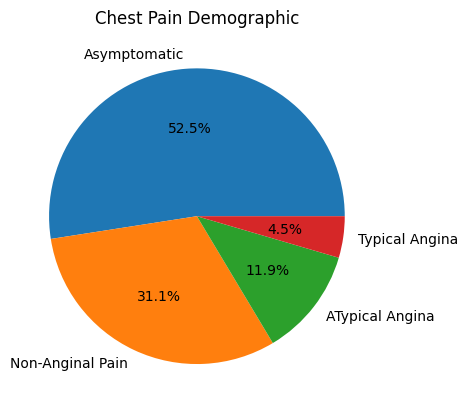

In [34]:
plts.pie(chest_pain_demograhic, labels = df.chest_pain_label.value_counts().index, autopct='%1.1f%%')
plts.title("Chest Pain Demographic")

In [35]:
df.head(10)

,id,age,sex,chest_pain_type,bp,cholesterol,blood_sugar,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,age_group,heart-rate_category,chest_pain_label,bp_category,cholesterol_category
0,630000,58,male,3,120,288,Normal,serious_heart_condition,145,Yes,0.8,2,3,3,Senior,medium,Non-Anginal Pain,Normal,High
1,630001,55,female,2,120,209,Normal,Normal_heart,172,No,0.0,1,0,3,Senior,high,ATypical Angina,Normal,Border_line
2,630002,54,male,4,120,268,Normal,Normal_heart,150,Yes,0.0,2,3,7,Senior,medium,Asymptomatic,Normal,High
3,630003,44,female,3,112,177,Normal,Normal_heart,168,No,0.9,1,0,3,Middle-Aged,high,Non-Anginal Pain,Normal,Normal
4,630004,43,male,1,138,267,Normal,Normal_heart,163,No,1.8,2,0,7,Middle-Aged,high,Typical Angina,Medium,High
5,630005,61,male,4,130,254,Normal,serious_heart_condition,139,Yes,1.4,2,0,7,Senior,medium,Asymptomatic,Medium,High
6,630006,48,female,2,120,330,Normal,serious_heart_condition,166,No,0.0,1,1,3,Middle-Aged,high,ATypical Angina,Normal,High
7,630007,57,male,4,142,282,Normal,Normal_heart,153,No,0.0,1,0,7,Senior,medium,Asymptomatic,High,High
8,630008,60,male,4,130,249,Normal,serious_heart_condition,131,Yes,0.4,2,1,7,Senior,medium,Asymptomatic,Medium,High
9,630009,43,female,3,120,250,Normal,serious_heart_condition,160,No,0.9,1,0,3,Middle-Aged,medium,Non-Anginal Pain,Normal,High


# EDA - Exploratory Data Analysis

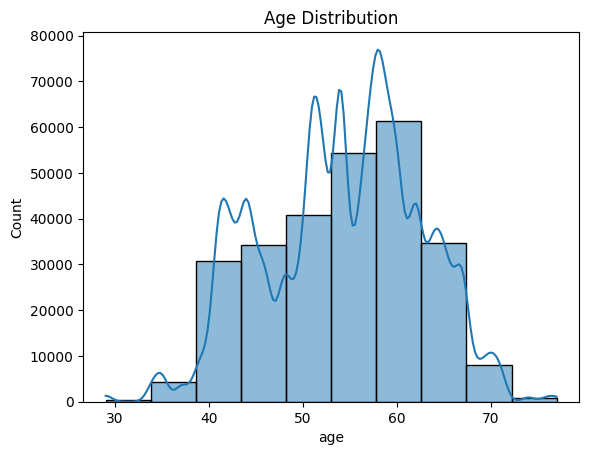

In [36]:
sns.histplot(df['age'], kde=True, bins=10)
plts.title("Age Distribution")
plts.show()


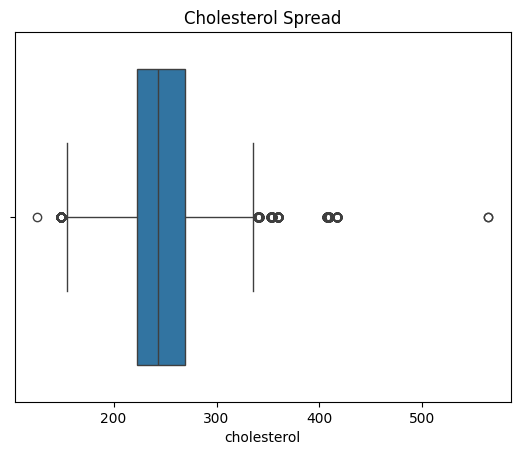

In [37]:
sns.boxplot(x=df['cholesterol'])
plts.title("Cholesterol Spread")
plts.show()


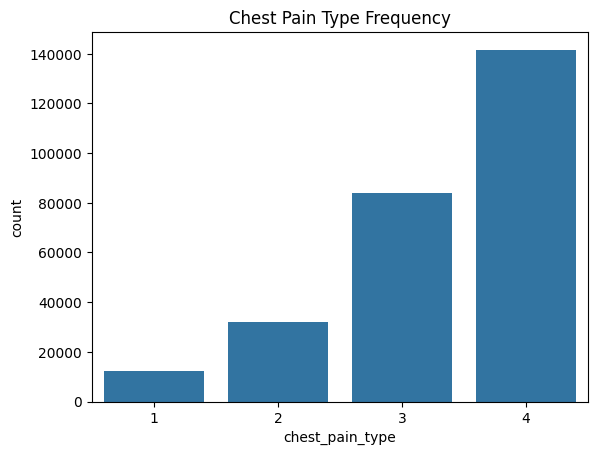

In [38]:
sns.countplot(x='chest_pain_type', data=df)
plts.title("Chest Pain Type Frequency")
plts.show()


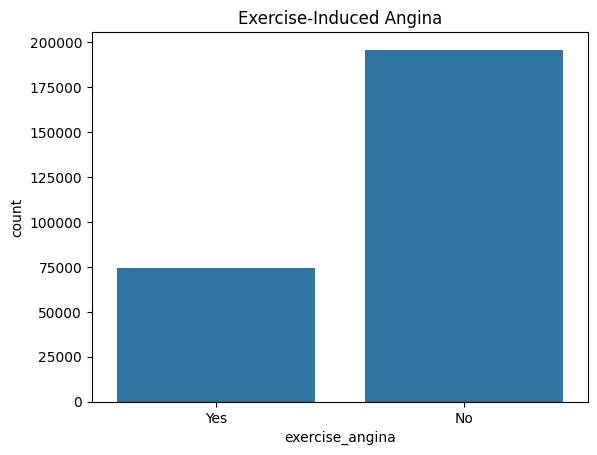

In [39]:
sns.countplot(x='exercise_angina', data=df)
plts.title("Exercise-Induced Angina")
plts.show()


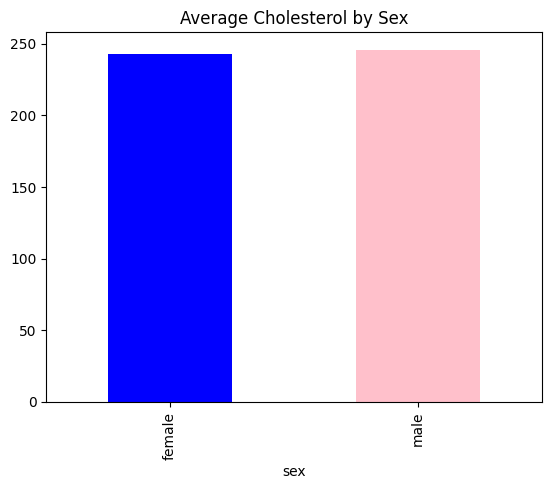

In [40]:
df.groupby('sex')['cholesterol'].mean().plot(kind='bar', color=['blue','pink'])
plts.title("Average Cholesterol by Sex")
plts.show()


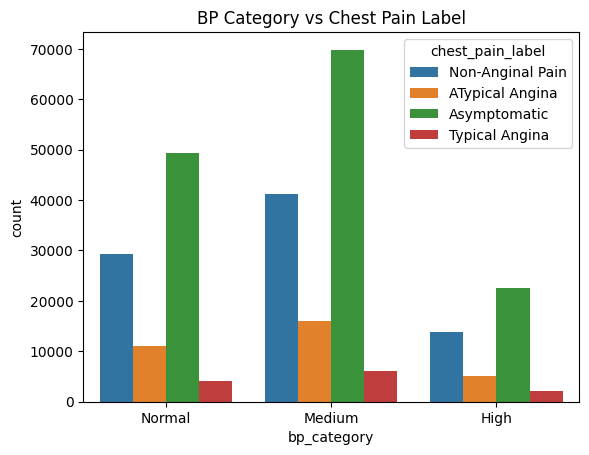

In [41]:
sns.countplot(x='bp_category', hue='chest_pain_label', data=df)
plts.title("BP Category vs Chest Pain Label")
plts.show()


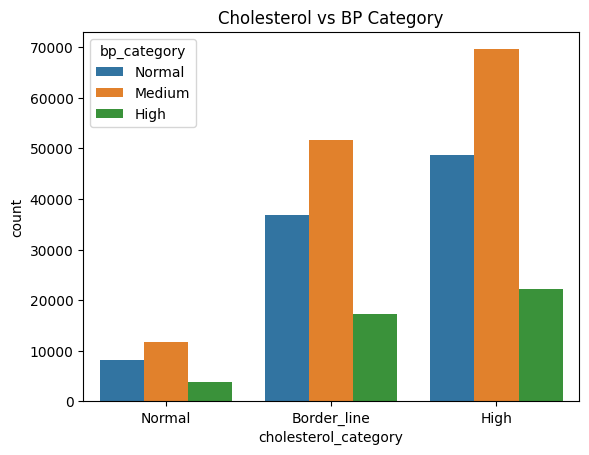

In [43]:
sns.countplot(x='cholesterol_category', hue='bp_category', data=df)
plts.title("Cholesterol vs BP Category")
plts.show()


# Creating new csv file with cleaned data

In [45]:
df.to_csv("cleaned_data.csv", index=False)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   id                       270000 non-null  int64   
 1   age                      270000 non-null  int64   
 2   sex                      270000 non-null  str     
 3   chest_pain_type          270000 non-null  int64   
 4   bp                       270000 non-null  int64   
 5   cholesterol              270000 non-null  int64   
 6   blood_sugar              270000 non-null  str     
 7   ekg_results              270000 non-null  str     
 8   max_hr                   270000 non-null  int64   
 9   exercise_angina          270000 non-null  str     
 10  st_depression            270000 non-null  float64 
 11  slope_of_st              270000 non-null  int64   
 12  number_of_vessels_fluro  270000 non-null  int64   
 13  thallium                 270000 non-null  int64   
 14 

# Making csv file

In [49]:
dh = pd.DataFrame({"organ condition": ['Healthy','Unhealthy']})
dh.to_csv('heart_type.csv', index=False)